# Thesis Defense: PEC Approach Figure

Generate two presentation-quality panels for the PEC approach slide:

1. **Left panel (2×2):** Magnitude + uncorrected vx, vy, vz — scaled to show the phase error gradient
2. **Right panel (3×1):** Correction fields vx, vy, vz — scaled to show the correction gradient

In [52]:
import platform
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from vascular_superenhancement.utils.path_config import load_path_config

config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

PATIENT_DATA_DIR = pc.working_dir / "patient_data"
DOWNSAMPLED_FOLDER = "downsampled_full_fov_128x128x64_crop-17.5"

PID = "Dublafer"
FRAME = 4

OUTPUT_DIR = Path("thesis_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

patient_dir = PATIENT_DATA_DIR / PID
ds_root = patient_dir / "nifti" / DOWNSAMPLED_FOLDER

print(f"Downsampled root: {ds_root}")
print(f"Exists: {ds_root.exists()}")

Downsampled root: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Dublafer/nifti/downsampled_full_fov_128x128x64_crop-17.5
Exists: True


In [53]:
COMPONENTS = ["vx", "vy", "vz"]
COMP_LABELS = {"vx": "$V_x$", "vy": "$V_y$", "vz": "$V_z$"}


def load_axial_slice(path: Path, z_idx: int | None = None) -> np.ndarray:
    vol = nib.load(str(path)).get_fdata(dtype=np.float32)
    if z_idx is None:
        z_idx = vol.shape[2] // 2
    return vol[:, :, z_idx]


mag = load_axial_slice(
    ds_root / "4d_flow_mag" / f"4d_flow_mag_{PID}_frame_{FRAME:02d}.nii.gz"
)

uncorr = {}
for comp in COMPONENTS:
    uncorr[comp] = load_axial_slice(
        ds_root / f"4d_flow_{comp}" / f"4d_flow_{comp}_{PID}_frame_{FRAME:02d}.nii.gz"
    )

corr_vel = {}
for comp in COMPONENTS:
    corr_vel[comp] = load_axial_slice(
        ds_root / f"4d_flow_{comp}_corr" / f"4d_flow_{comp}_corr_{PID}_frame_{FRAME:02d}.nii.gz"
    )

raw_correction = {comp: corr_vel[comp] - uncorr[comp] for comp in COMPONENTS}

man_venc_path = patient_dir / "nifti" / "velocity_correction" / f"poly_coefficients_{PID}.npz"
man_venc = float(np.load(str(man_venc_path))["venc"])
print(f"VENC: {man_venc:.1f} cm/s")

polyfit_correction = {}
for comp in COMPONENTS:
    corr_slice = load_axial_slice(
        ds_root / f"ground_truth_correction_{comp}_{PID}.nii.gz"
    )
    polyfit_correction[comp] = corr_slice * man_venc

print(f"Mag shape: {mag.shape}")
print(f"Velocity shape: {uncorr['vx'].shape}")
print(f"Polyfit correction shape: {polyfit_correction['vx'].shape}")

raw_corr_max = np.percentile(
    np.abs(np.concatenate([raw_correction[c].ravel() for c in COMPONENTS])), 99
)
poly_corr_max = np.percentile(
    np.abs(np.concatenate([polyfit_correction[c].ravel() for c in COMPONENTS])), 99
)
corr_max = max(raw_corr_max, poly_corr_max)
print(f"Raw correction 99th percentile:     {raw_corr_max:.1f} cm/s")
print(f"Polyfit correction 99th percentile: {poly_corr_max:.1f} cm/s")
print(f"Shared corr_max:                    {corr_max:.1f} cm/s")

VENC: 2500.0 cm/s
Mag shape: (128, 128)
Velocity shape: (128, 128)
Polyfit correction shape: (128, 128)
Raw correction 99th percentile:     68.4 cm/s
Polyfit correction 99th percentile: 81.2 cm/s
Shared corr_max:                    81.2 cm/s


Saved: thesis_figures/pec_left_uncorrected_velocity_Dublafer.png


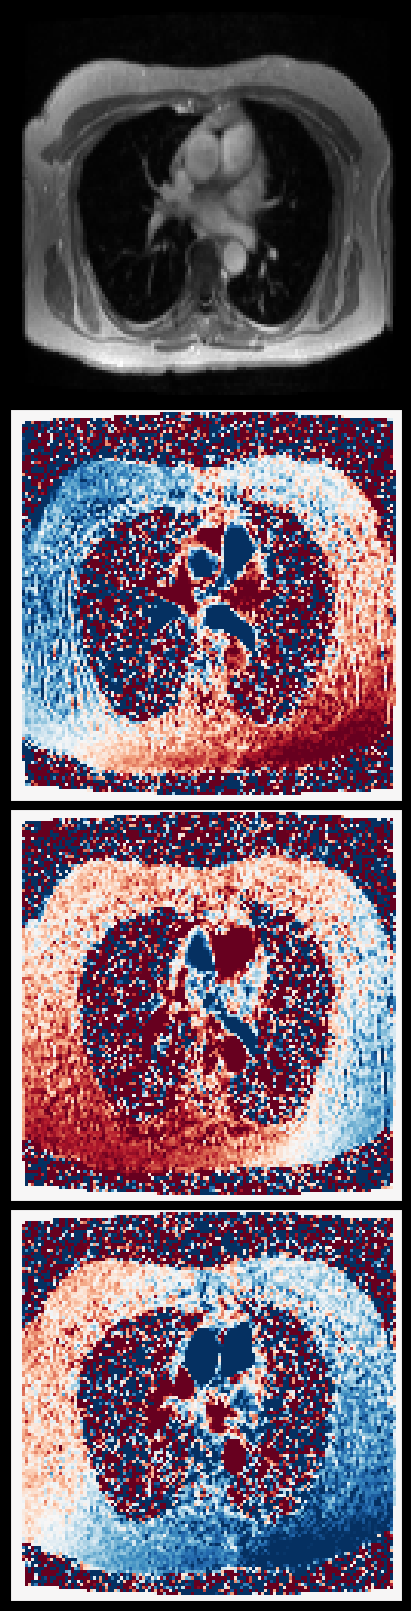

In [54]:
vel_scale = corr_max

vel_cmap = plt.cm.RdBu_r.copy()
vel_cmap.set_bad("black")

fig, axes = plt.subplots(4, 1, figsize=(4, 16), constrained_layout=True)
fig.patch.set_facecolor("black")

axes[0].imshow(mag.T, origin="upper", cmap="gray")

for ax, comp in zip(axes[1:], COMPONENTS):
    ax.imshow(
        uncorr[comp].T, origin="upper", cmap=vel_cmap,
        vmin=-vel_scale, vmax=vel_scale,
    )

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"pec_left_uncorrected_velocity_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

Saved: thesis_figures/pec_right_raw_correction_Dublafer.png


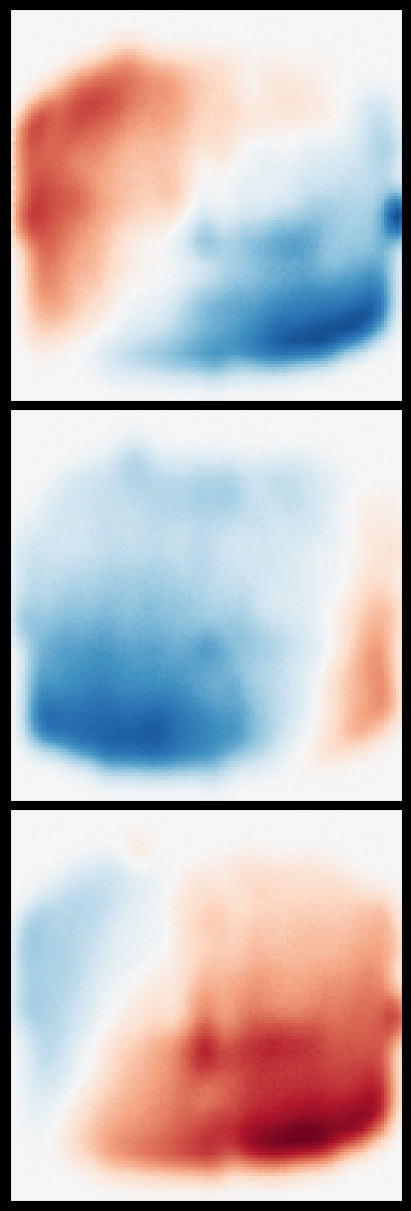

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(4, 12), constrained_layout=True)
fig.patch.set_facecolor("black")

for ax, comp in zip(axes, COMPONENTS):
    im = ax.imshow(
        raw_correction[comp].T, origin="upper", cmap=vel_cmap,
        vmin=-corr_max, vmax=corr_max,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"pec_right_raw_correction_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

Saved: thesis_figures/pec_right_polyfit_correction_Dublafer.png


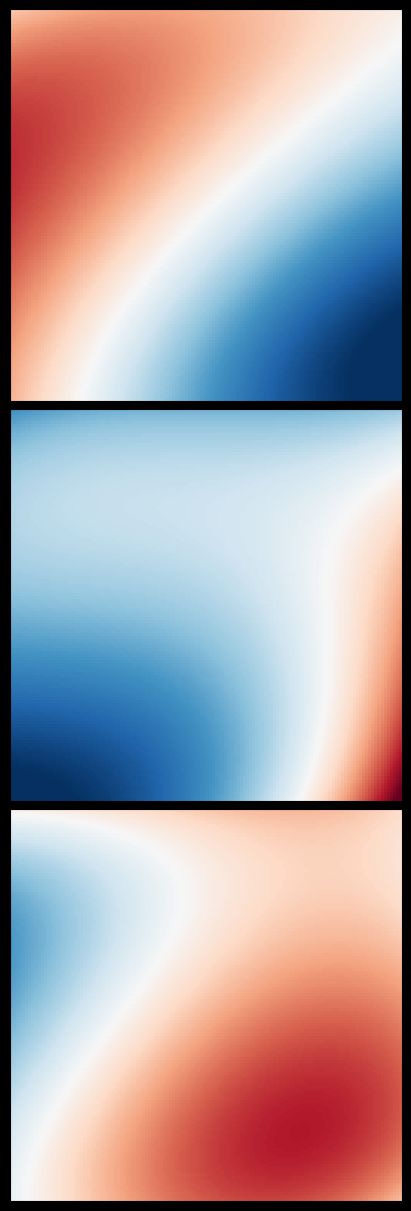

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(4, 12), constrained_layout=True)
fig.patch.set_facecolor("black")

for ax, comp in zip(axes, COMPONENTS):
    im = ax.imshow(
        polyfit_correction[comp].T, origin="upper", cmap=vel_cmap,
        vmin=-corr_max, vmax=corr_max,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"pec_right_polyfit_correction_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

Full FOV shape: (256, 256, 140)
Corr FOV shape: (256, 178, 140)
Voxel offset:   (0, 39, 0)
Using full_fov z-slice 70 (corr_fov mid = 70)
CNN corrected shape:  (256, 256)
Uncorr full FOV shape: (256, 256)
CNN correction 99th percentile: 151.3 cm/s
Saved: thesis_figures/pec_right_cnn_correction_Dublafer.png


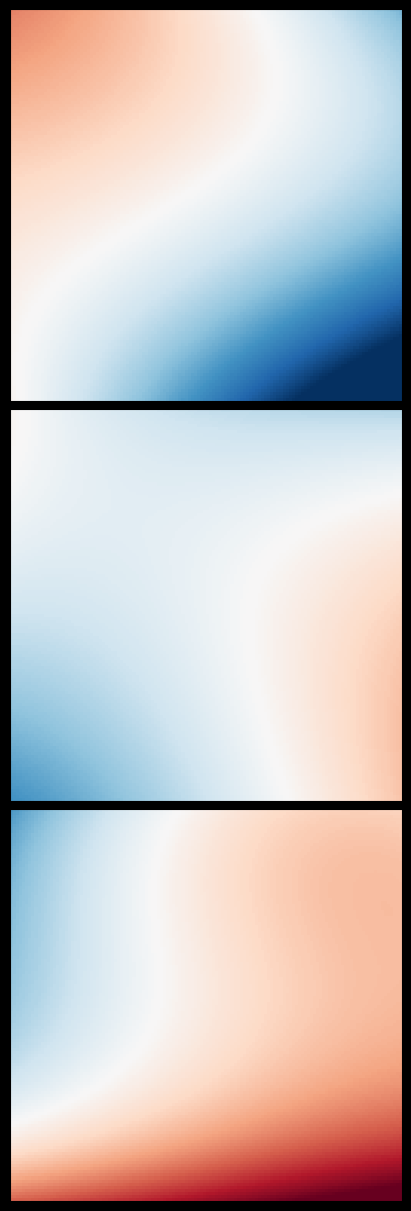

In [57]:
from scipy.ndimage import zoom as ndzoom

CNN_NIFTI_ROOT = Path.cwd().parents[1] / "working_dir" / "cnn_corrected_niftis"
cnn_vel_dir = CNN_NIFTI_ROOT / PID
full_fov_dir = patient_dir / "nifti"
corr_fov_dir = patient_dir / "nifti"

target_shape = mag.shape

full_fov_ref = nib.load(str(
    full_fov_dir / f"4d_flow_vx_{PID}_per_timepoint_full_fov" / f"4d_flow_vx_{PID}_frame_{FRAME:02d}.nii.gz"
))
corr_fov_ref = nib.load(str(
    corr_fov_dir / f"4d_flow_vx_{PID}_per_timepoint_corr_fov" / f"4d_flow_vx_{PID}_frame_{FRAME:02d}.nii.gz"
))

full_affine = full_fov_ref.affine
corr_affine = corr_fov_ref.affine
corr_shape = corr_fov_ref.shape

offset_phys = corr_affine[:3, 3] - full_affine[:3, 3]
spacing = np.abs(np.diag(full_affine[:3, :3]))
offset_vox = np.round(offset_phys / spacing).astype(int)

x0, y0, z0 = np.abs(offset_vox)
cx, cy, cz = corr_shape
print(f"Full FOV shape: {full_fov_ref.shape}")
print(f"Corr FOV shape: {corr_shape}")
print(f"Voxel offset:   ({x0}, {y0}, {z0})")

z_mid_full_fov = z0 + cz // 2
print(f"Using full_fov z-slice {z_mid_full_fov} (corr_fov mid = {cz // 2})")

cnn_corr_vel = {}
uncorr_full_fov = {}
for comp in COMPONENTS:
    cnn_corr_vel[comp] = load_axial_slice(
        cnn_vel_dir / f"4d_flow_{comp}_cnn_corr" / f"4d_flow_{comp}_cnn_corr_{PID}_frame_{FRAME:02d}.nii.gz",
        z_idx=z_mid_full_fov,
    )
    uncorr_full_fov[comp] = load_axial_slice(
        full_fov_dir / f"4d_flow_{comp}_{PID}_per_timepoint_full_fov"
        / f"4d_flow_{comp}_{PID}_frame_{FRAME:02d}.nii.gz",
        z_idx=z_mid_full_fov,
    )

cnn_correction_full = {comp: cnn_corr_vel[comp] - uncorr_full_fov[comp] for comp in COMPONENTS}

cnn_correction = {}
for comp in COMPONENTS:
    cropped = cnn_correction_full[comp][x0:x0+cx, y0:y0+cy]
    scale = np.array(target_shape) / np.array(cropped.shape)
    cnn_correction[comp] = ndzoom(cropped, scale, order=1)

cnn_corr_max = np.percentile(
    np.abs(np.concatenate([cnn_correction[c].ravel() for c in COMPONENTS])), 99
)
print(f"CNN corrected shape:  {cnn_corr_vel['vx'].shape}")
print(f"Uncorr full FOV shape: {uncorr_full_fov['vx'].shape}")
print(f"CNN correction 99th percentile: {cnn_corr_max:.1f} cm/s")

fig, axes = plt.subplots(3, 1, figsize=(4, 12), constrained_layout=True)
fig.patch.set_facecolor("black")

for ax, comp in zip(axes, COMPONENTS):
    ax.imshow(
        cnn_correction[comp].T, origin="upper", cmap=vel_cmap,
        vmin=-cnn_corr_max, vmax=cnn_corr_max,
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"pec_right_cnn_correction_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

## Tuning

Adjust parameters below to refine the figure if needed.

In [58]:
ref_vol = nib.load(
    str(ds_root / "4d_flow_mag" / f"4d_flow_mag_{PID}_frame_{FRAME:02d}.nii.gz")
)
n_z = ref_vol.shape[2]
print(f"Volume has {n_z} axial slices (indices 0–{n_z - 1})")
print(f"Current mid-slice: {n_z // 2}")
print(f"Current vel_scale:    ±{vel_scale:.1f} cm/s")
print(f"Current corr_max:     ±{corr_max:.1f} cm/s")
print(f"  raw_corr_max:       ±{raw_corr_max:.1f} cm/s")
print(f"  poly_corr_max:      ±{poly_corr_max:.1f} cm/s")
print()
print("To adjust, re-run cell 2 with a custom z_idx argument to load_axial_slice,")
print("or override vel_scale / corr_max before re-running cells 3–5.")

Volume has 64 axial slices (indices 0–63)
Current mid-slice: 32
Current vel_scale:    ±81.2 cm/s
Current corr_max:     ±81.2 cm/s
  raw_corr_max:       ±68.4 cm/s
  poly_corr_max:      ±81.2 cm/s

To adjust, re-run cell 2 with a custom z_idx argument to load_axial_slice,
or override vel_scale / corr_max before re-running cells 3–5.
